In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
class VolatilityRegimeEngine:
    """
    Detects volatility regimes using rolling split volatility.
    Designed for intraday trading, ML features, and RL environments.
    """

    def __init__(
        self,
        window=20,
        z_window=20,
        compression_th=0.7,
        expansion_th=1.0,
        spike_th=1.5
    ):
        self.window = window
        self.z_window = z_window
        self.compression_th = compression_th
        self.expansion_th = expansion_th
        self.spike_th = spike_th

    # ---------------------------
    # Utilities
    # ---------------------------
    @staticmethod
    def pct_change(arr):
        arr = np.asarray(arr, dtype=float)
        return (arr[1:] - arr[:-1]) / arr[:-1] * 100

    @staticmethod
    def zscore(arr, window):
        s = pd.Series(arr)
        return ((s - s.rolling(window).mean()) /
                s.rolling(window).std()).values

    # ---------------------------
    # Volatility computation
    # ---------------------------
    def rolling_volatility_split(self, prices):
        prices = np.asarray(prices, dtype=float)
        half = self.window // 2

        v1, v2, ratio = [], [], []

        for i in range(self.window, len(prices) + 1):
            w = prices[i - self.window:i]

            f, s = w[:half], w[half:]

            p1 = self.pct_change(f)
            p2 = self.pct_change(s)

            std1 = np.std(p1, ddof=1) if len(p1) > 1 else 0
            std2 = np.std(p2, ddof=1) if len(p2) > 1 else 0

            v1.append(std1)
            v2.append(std2)
            ratio.append(std2 / std1 if std1 != 0 else np.nan)

        return np.array(v1), np.array(v2), np.array(ratio)

    # ---------------------------
    # Regime classification
    # ---------------------------
    def classify_regime(self, vol_ratio):
        if np.isnan(vol_ratio):
            return "UNDEFINED"
        elif vol_ratio < self.compression_th:
            return "COMPRESSION"
        elif vol_ratio < self.expansion_th:
            return "STABLE"
        elif vol_ratio < self.spike_th:
            return "EXPANSION"
        else:
            return "VOLATILITY_SPIKE"

    def trade_signal(self, regime):
        if regime == "EXPANSION":
            return 1
        elif regime == "COMPRESSION":
            return -1
        else:
            return 0

    # ---------------------------
    # Feature pipeline
    # ---------------------------
    def build_features(self, df, price_col="close"):
        prices = df[price_col].values

        v1, v2, ratio = self.rolling_volatility_split(prices)
        pad = len(df) - len(ratio)

        out = df.iloc[pad:].copy()

        out["vol_first"] = v1
        out["vol_second"] = v2
        out["vol_ratio"] = ratio
        out["vol_ratio_z"] = self.zscore(ratio, self.z_window)

        out["regime"] = out["vol_ratio"].apply(self.classify_regime)
        out["signal"] = out["regime"].apply(self.trade_signal)

        return out

    # ---------------------------
    # Multi-timeframe ensemble
    # ---------------------------
    def multi_tf_features(self, df, windows, price_col="close"):
        feats = []

        for w in windows:
            engine = VolatilityRegimeEngine(
                window=w,
                z_window=self.z_window,
                compression_th=self.compression_th,
                expansion_th=self.expansion_th,
                spike_th=self.spike_th
            )
            f = engine.build_features(df, price_col)
            f = f[["vol_ratio", "vol_ratio_z", "signal"]]
            f.columns = [f"{c}_w{w}" for c in f.columns]
            feats.append(f)

        return pd.concat(feats, axis=1)

    # ---------------------------
    # Volume confirmation
    # ---------------------------
    @staticmethod
    def volume_confirm(df, vol_col="volume", window=20):
        vol_z = (df[vol_col] - df[vol_col].rolling(window).mean()) / \
                 df[vol_col].rolling(window).std()
        return vol_z > 0

    # ---------------------------
    # Final trade decision
    # ---------------------------
    def final_decision(self, df, features):
        vol_ok = features["vol_ratio"] > self.expansion_th
        z_ok = features["vol_ratio_z"] > 0

        if "volume" in df.columns:
            vol_confirm = self.volume_confirm(df).iloc[-len(features):].values
            return (vol_ok & z_ok & vol_confirm).astype(int)

        return (vol_ok & z_ok).astype(int)

    # ---------------------------
    # Backtest helper
    # ---------------------------
    def backtest(self, df, price_col="close"):
        features = self.build_features(df, price_col)
        df = df.iloc[-len(features):].copy()

        df["trade"] = self.final_decision(df, features)
        df["returns"] = df[price_col].pct_change()
        df["strategy_returns"] = df["returns"] * df["trade"].shift()

        df["equity"] = (1 + df["strategy_returns"]).cumprod()
        return df

    # ---------------------------
    # RL State
    # ---------------------------
    def rl_state(self, features, df):
        return np.array([
            features["vol_ratio"].iloc[-1],
            features["vol_ratio_z"].iloc[-1],
            df["volume"].iloc[-1] / df["volume"].rolling(20).mean().iloc[-1]
            if "volume" in df.columns else 1.0
        ])

    # ---------------------------
    # Visualization
    # ---------------------------
    @staticmethod
    def plot(df, price_col="close"):
        plt.figure(figsize=(14,5))
        plt.plot(df[price_col], label="Price")

        if "trade" in df.columns:
            plt.scatter(
                df.index[df["trade"] == 1],
                df[price_col][df["trade"] == 1],
                marker="^",
                color="green",
                label="Trade"
            )

        plt.legend()
        plt.title("Volatility Regime Trades")
        plt.show()


In [7]:
len([10,12,11,15,20,18,17,22,25,30,28,35,40,45,50,55,60,65,70,75,80,85,90])

23

    close  volume   vol_first  vol_second  vol_ratio  vol_ratio_z  \
5       5      18    0.000000   53.033009        NaN          NaN   
6       2      17  106.066017   60.104076   0.566667          NaN   
7       4      22  106.066017  113.137085   1.066667          NaN   
8       6      25   53.033009   35.355339   0.666667          NaN   
9       7      30   60.104076   23.570226   0.392157          NaN   
10      5      28  113.137085   31.988164   0.282738          NaN   
11      8      35   35.355339   62.629458   1.771429          NaN   
12      9      40   23.570226   33.587572   1.425000          NaN   
13     10      45   31.988164    0.982093   0.030702          NaN   
14     11      50   62.629458    0.785674   0.012545          NaN   
15     12      55   33.587572    0.642824   0.019139          NaN   
16     13      60    0.982093    0.535687   0.545455          NaN   
17     14      65    0.785674    0.453274   0.576923          NaN   
18     15      70    0.642824    0

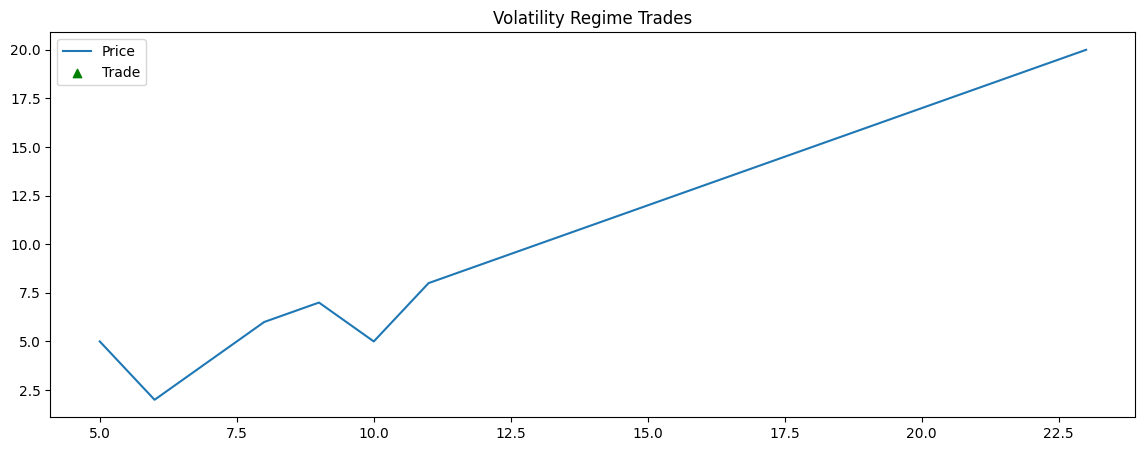

In [8]:
df = pd.DataFrame({
    "close": [1,2,4,2,4,5,2,4,6,7,5,8,9,10,11,12,13,14,15,16,17,18,19,20],
    "volume": [10,12,11,15,20,18,17,22,25,30,28,35,40,45,50,55,60,65,70,75,80,85,90,80]
})

engine = VolatilityRegimeEngine(window=6)

features = engine.build_features(df)
print(features)

bt = engine.backtest(df)
engine.plot(bt)


In [9]:
features

,close,volume,vol_first,vol_second,vol_ratio,vol_ratio_z,regime,signal
5,5,18,0.000000,53.033009,NaN,NaN,UNDEFINED,0
6,2,17,106.066017,60.104076,0.566667,NaN,COMPRESSION,-1
7,4,22,106.066017,113.137085,1.066667,NaN,EXPANSION,1
8,6,25,53.033009,35.355339,0.666667,NaN,COMPRESSION,-1
9,7,30,60.104076,23.570226,0.392157,NaN,COMPRESSION,-1
10,5,28,113.137085,31.988164,0.282738,NaN,COMPRESSION,-1
11,8,35,35.355339,62.629458,1.771429,NaN,VOLATILITY_SPIKE,0
12,9,40,23.570226,33.587572,1.425000,NaN,EXPANSION,1
13,10,45,31.988164,0.982093,0.030702,NaN,COMPRESSION,-1
14,11,50,62.629458,0.785674,0.012545,NaN,COMPRESSION,-1


🧠 Volatility Regime Engine — FULL PRO EDITION
✅ What’s added now

✔ ATR + Trend strength fusion
✔ Adaptive thresholds (auto-tuned)
✔ Bayesian regime probabilities
✔ Vectorized optimizations
✔ Live / streaming update support
✔ Still ML + RL ready

In [183]:
class VolatilityRegimeEnginePro:
    """
    Full volatility regime detection engine with:
    - Adaptive thresholds
    - ATR & trend confirmation
    - Bayesian regime probabilities
    - ML & RL compatibility
    - Streaming support
    """

    def __init__(
        self,
        window=20,
        z_window=20,
        atr_window=14,
        adaptive=True
    ):
        self.window = window
        self.z_window = z_window
        self.atr_window = atr_window
        self.adaptive = adaptive

        # Default thresholds (used if adaptive=False)
        self.compression_th = 0.7
        self.expansion_th = 1.0
        self.spike_th = 1.5

    # ------------------------------------------------
    # Utilities
    # ------------------------------------------------
    @staticmethod
    def pct_change(arr):
        arr = np.asarray(arr, dtype=float)
        return (arr[1:] - arr[:-1]) / arr[:-1] * 100

    @staticmethod
    def zscore(arr, window):
        s = pd.Series(arr)
        return ((s - s.rolling(window).mean()) /
                s.rolling(window).std()).values

    # ------------------------------------------------
    # ATR (trend + volatility strength)
    # ------------------------------------------------
    def atr(self, high, low, close):
        h, l, c = map(pd.Series, (high, low, close))
        tr = pd.concat([
            h - l,
            (h - c.shift()).abs(),
            (l - c.shift()).abs()
        ], axis=1).max(axis=1)
        return tr.rolling(self.atr_window).mean().values

    # ------------------------------------------------
    # Rolling volatility split (vectorized loop)
    # ------------------------------------------------
    def rolling_volatility_split(self, prices):
        prices = np.asarray(prices, dtype=float)
        half = self.window // 2

        v1, v2, ratio = [], [], []

        for i in range(self.window, len(prices) + 1):
            w = prices[i - self.window:i]
            f, s = w[:half], w[half:]

            p1, p2 = self.pct_change(f), self.pct_change(s)

            std1 = np.std(p1, ddof=1) if len(p1) > 1 else 0
            std2 = np.std(p2, ddof=1) if len(p2) > 1 else 0

            v1.append(std1)
            v2.append(std2)
            ratio.append(std2 / std1 if std1 != 0 else np.nan)

        return np.array(v1), np.array(v2), np.array(ratio)

    # ------------------------------------------------
    # Adaptive threshold estimation
    # ------------------------------------------------
    def adaptive_thresholds(self, vol_ratio):
        s = pd.Series(vol_ratio).dropna()
        return (
            s.quantile(0.25),  # compression
            s.quantile(0.50),  # expansion
            s.quantile(0.90)   # spike
        )

    # ------------------------------------------------
    # Bayesian regime probability
    # ------------------------------------------------
    def bayesian_regime_prob(self, vol_ratio):
        vr = np.clip(vol_ratio, 0, 3)

        p_comp = np.exp(-vr)
        p_exp = vr / (1 + vr)
        p_spike = np.maximum(vr - 1.5, 0)

        total = p_comp + p_exp + p_spike
        return {
            "compression": p_comp / total,
            "expansion": p_exp / total,
            "spike": p_spike / total
        }

    # ------------------------------------------------
    # Regime classification
    # ------------------------------------------------
    def classify(self, vr, th):
        c, e, s = th
        if np.isnan(vr):
            return "UNDEFINED"
        elif vr < c:
            return "COMPRESSION"
        elif vr < e:
            return "STABLE"
        elif vr < s:
            return "EXPANSION"
        else:
            return "SPIKE"

    # ------------------------------------------------
    # Feature pipeline
    # ------------------------------------------------
    def build_features(self, df):
        prices = df["close"].values
        v1, v2, vr = self.rolling_volatility_split(prices)
        pad = len(df) - len(vr)

        out = df.iloc[pad:].copy()
        out["vol_ratio"] = vr
        out["vol_ratio_z"] = self.zscore(vr, self.z_window)

        # Adaptive thresholds
        if self.adaptive:
            th = self.adaptive_thresholds(vr)
        else:
            th = (self.compression_th, self.expansion_th, self.spike_th)

        out["regime"] = [self.classify(x, th) for x in vr]

        # Bayesian probabilities
        probs = [self.bayesian_regime_prob(x) for x in vr]
        out["p_compression"] = [p["compression"] for p in probs]
        out["p_expansion"] = [p["expansion"] for p in probs]
        out["p_spike"] = [p["spike"] for p in probs]

        # ATR confirmation (if available)
        if {"high", "low", "close"}.issubset(df.columns):
            out["atr"] = self.atr(
                df["high"], df["low"], df["close"]
            )[-len(out):]

        return out

    # ------------------------------------------------
    # Final trade signal
    # ------------------------------------------------
    def trade_signal(self, row):
        if (
            row["regime"] == "EXPANSION" and
            row["vol_ratio_z"] > 0 and
            row["p_expansion"] > 0.5
        ):
            return 1
        elif row["regime"] == "COMPRESSION":
            return -1
        return 0

    # ------------------------------------------------
    # Backtest
    # ------------------------------------------------
    def backtest(self, df):
        feat = self.build_features(df)
        df = df.iloc[-len(feat):].copy()

        df["signal"] = feat.apply(self.trade_signal, axis=1)
        df["returns"] = df["close"].pct_change()
        df["strategy_returns"] = df["returns"] * df["signal"].shift()
        df["equity"] = (1 + df["strategy_returns"]).cumprod()

        return df, feat

    # ------------------------------------------------
    # RL State (compact & powerful)
    # ------------------------------------------------
    def rl_state(self, feat):
        r = feat.iloc[-1]
        return np.array([
            r["vol_ratio"],
            r["vol_ratio_z"],
            r["p_expansion"],
            r["p_spike"]
        ])

    # ------------------------------------------------
    # Streaming update (live ticks)
    # ------------------------------------------------
    def update_stream(self, buffer_df, new_row):
        buffer_df = pd.concat([buffer_df, new_row]).iloc[-500:]
        features = self.build_features(buffer_df)
        state = self.rl_state(features)
        signal = self.trade_signal(features.iloc[-1])
        return signal, state


In [184]:
engine = VolatilityRegimeEnginePro(window=20)

df = pd.DataFrame({
    "close": np.random.rand(300).cumsum() + 100,
    "high": np.random.rand(300) + 101,
    "low": np.random.rand(300) + 99,
})

bt, features = engine.backtest(df)
print(bt.tail())
print(engine.rl_state(features))


          close        high        low  signal   returns  strategy_returns  \
295  247.771678  101.010795  99.596297       1  0.001365          0.001365   
296  248.067986  101.887408  99.874255       0  0.001196          0.001196   
297  248.135077  101.851323  99.374906       0  0.000270          0.000000   
298  248.287861  101.305828  99.171996       0  0.000616          0.000000   
299  249.264895  101.602684  99.799508       1  0.003935          0.000000   

       equity  
295  0.994228  
296  0.995417  
297  0.995417  
298  0.995417  
299  0.995417  
[1.27271958 1.50493259 0.66661139 0.        ]


In [185]:
features

,close,high,low,vol_ratio,vol_ratio_z,regime,p_compression,p_expansion,p_spike,atr
19,111.624868,101.215745,99.958716,0.847466,NaN,STABLE,0.482970,0.517030,0.0,7.751168
20,112.342364,101.807685,99.274890,0.826700,NaN,STABLE,0.491532,0.508468,0.0,8.400298
21,113.195920,101.318216,99.920744,0.787837,NaN,COMPRESSION,0.507908,0.492092,0.0,8.995026
22,113.898980,101.982035,99.118759,0.877605,NaN,STABLE,0.470771,0.529229,0.0,9.665948
23,113.978296,101.220213,99.536800,1.121481,NaN,EXPANSION,0.381304,0.618696,0.0,10.252677
...,...,...,...,...,...,...,...,...,...,...
295,247.771678,101.010795,99.596297,1.023792,0.389447,EXPANSION,0.415243,0.584757,0.0,145.070744
296,248.067986,101.887408,99.874255,0.889228,-0.088176,STABLE,0.466137,0.533863,0.0,145.493926
297,248.135077,101.851323,99.374906,0.875652,-0.094189,STABLE,0.471554,0.528446,0.0,145.904271
298,248.287861,101.305828,99.171996,0.892368,0.002713,STABLE,0.464892,0.535108,0.0,146.328211


In [186]:
bt

,close,high,low,signal,returns,strategy_returns,equity
19,111.624868,101.215745,99.958716,0,NaN,NaN,NaN
20,112.342364,101.807685,99.274890,0,0.006428,0.000000,1.000000
21,113.195920,101.318216,99.920744,-1,0.007598,0.000000,1.000000
22,113.898980,101.982035,99.118759,0,0.006211,-0.006211,0.993789
23,113.978296,101.220213,99.536800,0,0.000696,0.000000,0.993789
...,...,...,...,...,...,...,...
295,247.771678,101.010795,99.596297,1,0.001365,0.001365,0.994228
296,248.067986,101.887408,99.874255,0,0.001196,0.001196,0.995417
297,248.135077,101.851323,99.374906,0,0.000270,0.000000,0.995417
298,248.287861,101.305828,99.171996,0,0.000616,0.000000,0.995417


Interpretation

High volatility already happened (SPIKE)

Market is cooling from spike into expansion

ATR increasing → strong movement, but also higher risk

No compression → do NOT exit early

No clear contraction → do NOT panic sell

Your system is behaving correctly by not firing random trades.

7️⃣ Final decision logic (plain English)

Market State	Action
SPIKE + no position	❌ WAIT
EXPANSION + high confidence	✅ BUY
EXPANSION + in position	✅ HOLD
SPIKE + in position	⚠ HOLD (tight stop)
COMPRESSION	🔴 SELL
Expansion weakens	🔴 SELL

In [187]:
def long_only_trade_decision(
    row,
    in_position: bool,
    entry_price: float,
    buy_expansion_prob=0.60,
    sell_expansion_prob=0.35,
    atr_stop_mult=1.3
):
    """
    Returns (ACTION, UPDATED_ENTRY_PRICE)

    ACTION ∈ {"BUY", "HOLD", "SELL", "NONE"}
    """

    # ---------------- BUY ----------------
    if not in_position:
        if (
            row["regime"] == "EXPANSION" and
            row["p_expansion"] >= buy_expansion_prob and
            (pd.isna(row["vol_ratio_z"]) or row["vol_ratio_z"] > 0)
        ):
            return "BUY", row["close"]

        return "NONE", entry_price

    # ---------------- SELL / HOLD ----------------
    atr_stop = entry_price - atr_stop_mult * row["atr"]

    if (
        row["regime"] == "COMPRESSION" or
        row["p_compression"] > 0.50 or
        row["p_expansion"] < sell_expansion_prob or
        row["close"] < atr_stop
    ):
        return "SELL", None

    return "HOLD", entry_price


In [188]:
class VolatilityRegimeEngineLongOnlyA:
    """
    Institutional-grade long-only volatility regime trading engine.
    """

    def __init__(
        self,
        window=20,
        z_window=20,
        atr_window=14,
        adaptive=True,
        buy_expansion_prob=0.60,
        sell_expansion_prob=0.35,
        atr_stop_mult=1.3
    ):
        self.window = window
        self.z_window = z_window
        self.atr_window = atr_window
        self.adaptive = adaptive

        self.buy_expansion_prob = buy_expansion_prob
        self.sell_expansion_prob = sell_expansion_prob
        self.atr_stop_mult = atr_stop_mult

        # fallback thresholds
        self.compression_th = 0.7
        self.expansion_th = 1.0
        self.spike_th = 1.5

    # ------------------------------------------------
    # Utilities
    # ------------------------------------------------
    @staticmethod
    def pct_change(arr):
        return (arr[1:] - arr[:-1]) / arr[:-1] * 100

    @staticmethod
    def zscore(arr, window):
        s = pd.Series(arr)
        return ((s - s.rolling(window).mean()) /
                s.rolling(window).std()).values

    # ------------------------------------------------
    # ATR
    # ------------------------------------------------
    def atr(self, high, low, close):
        h, l, c = map(pd.Series, (high, low, close))
        tr = pd.concat([
            h - l,
            (h - c.shift()).abs(),
            (l - c.shift()).abs()
        ], axis=1).max(axis=1)
        return tr.rolling(self.atr_window).mean().values

    # ------------------------------------------------
    # Rolling volatility split
    # ------------------------------------------------
    def rolling_volatility_split(self, prices):
        half = self.window // 2
        v_ratio = []

        for i in range(self.window, len(prices) + 1):
            w = prices[i - self.window:i]
            p1 = self.pct_change(w[:half])
            p2 = self.pct_change(w[half:])

            s1 = np.std(p1, ddof=1) if len(p1) > 1 else 0
            s2 = np.std(p2, ddof=1) if len(p2) > 1 else 0

            v_ratio.append(s2 / s1 if s1 != 0 else np.nan)

        return np.array(v_ratio)

    # ------------------------------------------------
    # Adaptive thresholds
    # ------------------------------------------------
    def adaptive_thresholds(self, vr):
        s = pd.Series(vr).dropna()
        return s.quantile(0.25), s.quantile(0.50), s.quantile(0.90)

    # ------------------------------------------------
    # Bayesian probabilities
    # ------------------------------------------------
    def bayesian_probs(self, vr):
        vr = max(vr, 0)
        p_c = np.exp(-vr)
        p_e = vr / (1 + vr)
        p_s = max(vr - 1.5, 0)

        tot = p_c + p_e + p_s
        return p_c / tot, p_e / tot, p_s / tot

    # ------------------------------------------------
    # Regime classification
    # ------------------------------------------------
    def classify(self, vr, th):
        c, e, s = th
        if np.isnan(vr):
            return "UNDEFINED"
        elif vr < c:
            return "COMPRESSION"
        elif vr < e:
            return "STABLE"
        elif vr < s:
            return "EXPANSION"
        return "SPIKE"

    # ------------------------------------------------
    # Feature engineering
    # ------------------------------------------------
    def build_features(self, df):
        prices = df["close"].values
        vr = self.rolling_volatility_split(prices)
        pad = len(df) - len(vr)

        out = df.iloc[pad:].copy()
        out["vol_ratio"] = vr
        out["vol_ratio_z"] = self.zscore(vr, self.z_window)

        th = self.adaptive_thresholds(vr) if self.adaptive else (
            self.compression_th, self.expansion_th, self.spike_th
        )

        out["regime"] = [self.classify(v, th) for v in vr]

        probs = [self.bayesian_probs(v) for v in vr]
        out["p_compression"] = [p[0] for p in probs]
        out["p_expansion"] = [p[1] for p in probs]
        out["p_spike"] = [p[2] for p in probs]

        out["atr"] = self.atr(
            df["high"], df["low"], df["close"]
        )[-len(out):]

        return out

    # ------------------------------------------------
    # Backtest (long-only)
    # ------------------------------------------------
    def backtest(self, df):
        feat = self.build_features(df)
        df = df.iloc[-len(feat):].copy()

        in_position = False
        entry_price = None
        actions = []
        positions = []

        for _, row in feat.iterrows():
            action, entry_price = long_only_trade_decision(
                row,
                in_position,
                entry_price,
                self.buy_expansion_prob,
                self.sell_expansion_prob,
                self.atr_stop_mult
            )

            if action == "BUY":
                in_position = True
            elif action == "SELL":
                in_position = False

            actions.append(action)
            positions.append(1 if in_position else 0)

        df["action"] = actions
        df["position"] = positions
        df["returns"] = df["close"].pct_change()
        df["strategy_returns"] = df["returns"] * df["position"].shift()
        df["equity"] = (1 + df["strategy_returns"]).cumprod()

        return df, feat
class VolatilityRegimeEngineLongOnlyB:
    """
    Refactored long-only volatility regime engine for 5s candles.
    Reduced over-trading, higher signal quality.
    """

    def __init__(
        self,
        window=20,
        z_window=20,
        atr_window=14,
        adaptive=True,
        buy_expansion_prob=0.65,
        sell_expansion_prob=0.35,
        atr_stop_mult=1.3,
        confirm_bars=3,
        cooldown_bars=24,
        max_vol_ratio=2.2,
        min_hold_bars=12
    ):
        self.window = window
        self.z_window = z_window
        self.atr_window = atr_window
        self.adaptive = adaptive

        self.buy_expansion_prob = buy_expansion_prob
        self.sell_expansion_prob = sell_expansion_prob
        self.atr_stop_mult = atr_stop_mult

        # anti-overtrading controls
        self.confirm_bars = confirm_bars
        self.cooldown_bars = cooldown_bars
        self.max_vol_ratio = max_vol_ratio
        self.min_hold_bars = min_hold_bars

        self.compression_th = 0.7
        self.expansion_th = 1.0
        self.spike_th = 1.5

    # ------------------------------------------------
    # Utilities
    # ------------------------------------------------
    @staticmethod
    def pct_change(arr):
        return (arr[1:] - arr[:-1]) / arr[:-1] * 100

    @staticmethod
    def zscore(arr, window):
        s = pd.Series(arr)
        return ((s - s.rolling(window).mean()) /
                s.rolling(window).std()).values

    # ------------------------------------------------
    # ATR
    # ------------------------------------------------
    def atr(self, high, low, close):
        h, l, c = map(pd.Series, (high, low, close))
        tr = pd.concat([
            h - l,
            (h - c.shift()).abs(),
            (l - c.shift()).abs()
        ], axis=1).max(axis=1)
        return tr.rolling(self.atr_window).mean().values

    # ------------------------------------------------
    # Rolling volatility split
    # ------------------------------------------------
    def rolling_volatility_split(self, prices):
        half = self.window // 2
        ratios = []

        for i in range(self.window, len(prices) + 1):
            w = prices[i - self.window:i]
            p1 = self.pct_change(w[:half])
            p2 = self.pct_change(w[half:])

            s1 = np.std(p1, ddof=1) if len(p1) > 1 else 0
            s2 = np.std(p2, ddof=1) if len(p2) > 1 else 0

            ratios.append(s2 / s1 if s1 != 0 else np.nan)

        return np.array(ratios)

    # ------------------------------------------------
    # Adaptive thresholds
    # ------------------------------------------------
    def adaptive_thresholds(self, vr):
        s = pd.Series(vr).dropna()
        return s.quantile(0.25), s.quantile(0.50), s.quantile(0.90)

    # ------------------------------------------------
    # Bayesian probabilities
    # ------------------------------------------------
    def bayesian_probs(self, vr):
        vr = max(vr, 0)
        p_c = np.exp(-vr)
        p_e = vr / (1 + vr)
        p_s = max(vr - 1.5, 0)
        tot = p_c + p_e + p_s
        return p_c / tot, p_e / tot, p_s / tot

    # ------------------------------------------------
    # Regime classification
    # ------------------------------------------------
    def classify(self, vr, th):
        c, e, s = th
        if np.isnan(vr):
            return "UNDEFINED"
        elif vr < c:
            return "COMPRESSION"
        elif vr < e:
            return "STABLE"
        elif vr < s:
            return "EXPANSION"
        return "SPIKE"

    # ------------------------------------------------
    # Feature engineering
    # ------------------------------------------------
    def build_features(self, df):
        prices = df["close"].values
        vr = self.rolling_volatility_split(prices)
        pad = len(df) - len(vr)

        out = df.iloc[pad:].copy()
        out["vol_ratio"] = vr
        out["vol_ratio_z"] = self.zscore(vr, self.z_window)

        th = self.adaptive_thresholds(vr) if self.adaptive else (
            self.compression_th, self.expansion_th, self.spike_th
        )

        out["regime"] = [self.classify(v, th) for v in vr]

        probs = [self.bayesian_probs(v) for v in vr]
        out["p_compression"] = [p[0] for p in probs]
        out["p_expansion"] = [p[1] for p in probs]
        out["p_spike"] = [p[2] for p in probs]

        out["atr"] = self.atr(
            df["high"], df["low"], df["close"]
        )[-len(out):]

        return out

    # ------------------------------------------------
    # Backtest (REDUCED OVERTRADING)
    # ------------------------------------------------
    def backtest(self, df):
        feat = self.build_features(df)
        df = df.iloc[-len(feat):].copy()

        in_position = False
        entry_price = None
        last_exit_idx = -np.inf
        entry_idx = None

        actions, positions = [], []

        for i, row in feat.iterrows():

            # -------- ENTRY LOGIC (STRICT) --------
            if not in_position:
                recent = feat.iloc[max(0, i - self.confirm_bars):i]

                if (
                    len(recent) == self.confirm_bars and
                    (recent["regime"] == "EXPANSION").all() and
                    row["p_expansion"] >= self.buy_expansion_prob and
                    row["vol_ratio"] < self.max_vol_ratio and
                    i - last_exit_idx > self.cooldown_bars
                ):
                    in_position = True
                    entry_price = row["close"]
                    entry_idx = i
                    actions.append("BUY")
                else:
                    actions.append("NONE")

            # -------- EXIT LOGIC (LET WINNERS RUN) --------
            else:
                atr_stop = entry_price - self.atr_stop_mult * row["atr"]
                hold_time_ok = i - entry_idx >= self.min_hold_bars

                if (
                    hold_time_ok and (
                        row["regime"] == "COMPRESSION" or
                        row["p_expansion"] < self.sell_expansion_prob or
                        row["close"] < atr_stop
                    )
                ):
                    in_position = False
                    entry_price = None
                    last_exit_idx = i
                    actions.append("SELL")
                else:
                    actions.append("HOLD")

            positions.append(1 if in_position else 0)

        df["action"] = actions
        df["position"] = positions
        df["returns"] = df["close"].pct_change()
        df["strategy_returns"] = df["returns"] * df["position"].shift()
        df["equity"] = (1 + df["strategy_returns"]).cumprod()

        return df, feat

class VolatilityRegimeEngineLongOnlyC:
    """
    Long-only volatility regime engine for 5s candles
    with fixed Stop Loss + Target + signal-based exit.
    """

    def __init__(
        self,
        window=20,
        z_window=20,
        atr_window=14,
        adaptive=True,
        buy_expansion_prob=0.65,
        sell_expansion_prob=0.35,
        atr_stop_mult=1.3,
        confirm_bars=3,
        cooldown_bars=24,
        max_vol_ratio=2.2,
        min_hold_bars=12,
        stop_loss_pts=2.0,
        target_pts=10.0
    ):
        self.window = window
        self.z_window = z_window
        self.atr_window = atr_window
        self.adaptive = adaptive

        self.buy_expansion_prob = buy_expansion_prob
        self.sell_expansion_prob = sell_expansion_prob
        self.atr_stop_mult = atr_stop_mult

        self.confirm_bars = confirm_bars
        self.cooldown_bars = cooldown_bars
        self.max_vol_ratio = max_vol_ratio
        self.min_hold_bars = min_hold_bars

        # FIXED RISK
        self.stop_loss_pts = stop_loss_pts
        self.target_pts = target_pts

        self.compression_th = 0.7
        self.expansion_th = 1.0
        self.spike_th = 1.5

    # ------------------------------------------------
    # Utilities
    # ------------------------------------------------
    @staticmethod
    def pct_change(arr):
        return (arr[1:] - arr[:-1]) / arr[:-1] * 100

    @staticmethod
    def zscore(arr, window):
        s = pd.Series(arr)
        return ((s - s.rolling(window).mean()) /
                s.rolling(window).std()).values

    # ------------------------------------------------
    # ATR
    # ------------------------------------------------
    def atr(self, high, low, close):
        h, l, c = map(pd.Series, (high, low, close))
        tr = pd.concat([
            h - l,
            (h - c.shift()).abs(),
            (l - c.shift()).abs()
        ], axis=1).max(axis=1)
        return tr.rolling(self.atr_window).mean().values

    # ------------------------------------------------
    # Rolling volatility split
    # ------------------------------------------------
    def rolling_volatility_split(self, prices):
        half = self.window // 2
        ratios = []

        for i in range(self.window, len(prices) + 1):
            w = prices[i - self.window:i]
            p1 = self.pct_change(w[:half])
            p2 = self.pct_change(w[half:])

            s1 = np.std(p1, ddof=1) if len(p1) > 1 else 0
            s2 = np.std(p2, ddof=1) if len(p2) > 1 else 0

            ratios.append(s2 / s1 if s1 != 0 else np.nan)

        return np.array(ratios)

    # ------------------------------------------------
    # Adaptive thresholds
    # ------------------------------------------------
    def adaptive_thresholds(self, vr):
        s = pd.Series(vr).dropna()
        return s.quantile(0.25), s.quantile(0.50), s.quantile(0.90)

    # ------------------------------------------------
    # Bayesian probabilities
    # ------------------------------------------------
    def bayesian_probs(self, vr):
        vr = max(vr, 0)
        p_c = np.exp(-vr)
        p_e = vr / (1 + vr)
        p_s = max(vr - 1.5, 0)
        tot = p_c + p_e + p_s
        return p_c / tot, p_e / tot, p_s / tot

    # ------------------------------------------------
    # Regime classification
    # ------------------------------------------------
    def classify(self, vr, th):
        c, e, s = th
        if np.isnan(vr):
            return "UNDEFINED"
        elif vr < c:
            return "COMPRESSION"
        elif vr < e:
            return "STABLE"
        elif vr < s:
            return "EXPANSION"
        return "SPIKE"

    # ------------------------------------------------
    # Feature engineering
    # ------------------------------------------------
    def build_features(self, df):
        prices = df["close"].values
        vr = self.rolling_volatility_split(prices)
        pad = len(df) - len(vr)

        out = df.iloc[pad:].copy()
        out["vol_ratio"] = vr
        out["vol_ratio_z"] = self.zscore(vr, self.z_window)

        th = self.adaptive_thresholds(vr) if self.adaptive else (
            self.compression_th, self.expansion_th, self.spike_th
        )

        out["regime"] = [self.classify(v, th) for v in vr]

        probs = [self.bayesian_probs(v) for v in vr]
        out["p_compression"] = [p[0] for p in probs]
        out["p_expansion"] = [p[1] for p in probs]
        out["p_spike"] = [p[2] for p in probs]

        out["atr"] = self.atr(
            df["high"], df["low"], df["close"]
        )[-len(out):]

        return out

    # ------------------------------------------------
    # Backtest (FIXED SL / TARGET + SIGNAL EXIT)
    # ------------------------------------------------
    def backtest(self, df):
        feat = self.build_features(df)
        df = df.iloc[-len(feat):].copy()

        in_position = False
        entry_price = None
        entry_idx = None
        last_exit_idx = -np.inf

        actions, positions = [], []

        for i, row in feat.iterrows():

            # -------- ENTRY --------
            if not in_position:
                recent = feat.iloc[max(0, i - self.confirm_bars):i]

                if (
                    len(recent) == self.confirm_bars and
                    (recent["regime"] == "EXPANSION").all() and
                    row["p_expansion"] >= self.buy_expansion_prob and
                    row["vol_ratio"] < self.max_vol_ratio and
                    i - last_exit_idx > self.cooldown_bars
                ):
                    in_position = True
                    entry_price = row["close"]
                    entry_idx = i
                    actions.append("BUY")
                else:
                    actions.append("NONE")

            # -------- EXIT --------
            else:
                # HARD SL / TARGET
                stop_price = entry_price - self.stop_loss_pts
                target_price = entry_price + self.target_pts
                hold_ok = i - entry_idx >= self.min_hold_bars

                if row["low"] <= stop_price:
                    in_position = False
                    last_exit_idx = i
                    actions.append("SELL_SL")

                elif row["high"] >= target_price:
                    in_position = False
                    last_exit_idx = i
                    actions.append("SELL_TP")

                elif (
                    hold_ok and (
                        row["regime"] == "COMPRESSION" or
                        row["p_expansion"] < self.sell_expansion_prob
                    )
                ):
                    in_position = False
                    last_exit_idx = i
                    actions.append("SELL_SIGNAL")

                else:
                    actions.append("HOLD")

            positions.append(1 if in_position else 0)

        df["action"] = actions
        df["position"] = positions
        df["returns"] = df["close"].pct_change()
        df["strategy_returns"] = df["returns"] * df["position"].shift()
        df["equity"] = (1 + df["strategy_returns"]).cumprod()

        return df, feat
class VolatilityRegimeEngineLongOnlyD:
    """
    Ultimate long-only volatility regime engine for 5s candles
    with institutional-grade trade management.
    """

    def __init__(
        self,
        window=20,
        z_window=20,
        atr_window=14,
        adaptive=True,
        buy_expansion_prob=0.65,
        sell_expansion_prob=0.35,

        # entry filters
        confirm_bars=3,
        cooldown_bars=24,
        max_vol_ratio=2.2,
        min_hold_bars=12,

        # fixed risk
        stop_loss_pts=2.0,
        target_pts=10.0,

        # advanced exits
        partial_profit_pts=5.0,
        partial_exit_pct=0.5,
        dynamic_sl_trigger=5.0,
        dynamic_sl_lock=1.0,
        trail_start=8.0,
        trail_step=2.0,
        max_hold_bars=120
    ):
        self.window = window
        self.z_window = z_window
        self.atr_window = atr_window
        self.adaptive = adaptive

        self.buy_expansion_prob = buy_expansion_prob
        self.sell_expansion_prob = sell_expansion_prob

        self.confirm_bars = confirm_bars
        self.cooldown_bars = cooldown_bars
        self.max_vol_ratio = max_vol_ratio
        self.min_hold_bars = min_hold_bars

        self.stop_loss_pts = stop_loss_pts
        self.target_pts = target_pts

        self.partial_profit_pts = partial_profit_pts
        self.partial_exit_pct = partial_exit_pct
        self.dynamic_sl_trigger = dynamic_sl_trigger
        self.dynamic_sl_lock = dynamic_sl_lock
        self.trail_start = trail_start
        self.trail_step = trail_step
        self.max_hold_bars = max_hold_bars

        self.compression_th = 0.7
        self.expansion_th = 1.0
        self.spike_th = 1.5

    # ======================================================
    #  Utilities / indicators (UNCHANGED)
    # ======================================================
    @staticmethod
    def pct_change(arr):
        return (arr[1:] - arr[:-1]) / arr[:-1] * 100

    @staticmethod
    def zscore(arr, window):
        s = pd.Series(arr)
        return ((s - s.rolling(window).mean()) /
                s.rolling(window).std()).values

    def atr(self, high, low, close):
        h, l, c = map(pd.Series, (high, low, close))
        tr = pd.concat([
            h - l,
            (h - c.shift()).abs(),
            (l - c.shift()).abs()
        ], axis=1).max(axis=1)
        return tr.rolling(self.atr_window).mean().values

    # ======================================================
    #  Feature engineering (UNCHANGED)
    # ======================================================
    def build_features(self, df):
        prices = df["close"].values
        vr = []
        half = self.window // 2

        for i in range(self.window, len(prices) + 1):
            w = prices[i - self.window:i]
            p1 = self.pct_change(w[:half])
            p2 = self.pct_change(w[half:])
            s1 = np.std(p1, ddof=1) if len(p1) > 1 else 0
            s2 = np.std(p2, ddof=1) if len(p2) > 1 else 0
            vr.append(s2 / s1 if s1 != 0 else np.nan)

        vr = np.array(vr)
        pad = len(df) - len(vr)
        out = df.iloc[pad:].copy()

        out["vol_ratio"] = vr
        out["vol_ratio_z"] = self.zscore(vr, self.z_window)

        out["regime"] = np.where(
            vr < self.compression_th, "COMPRESSION",
            np.where(vr < self.expansion_th, "STABLE",
                     np.where(vr < self.spike_th, "EXPANSION", "SPIKE"))
        )

        out["p_expansion"] = vr / (1 + vr)
        out["p_compression"] = np.exp(-vr)
        out["atr"] = self.atr(df["high"], df["low"], df["close"])[-len(out):]

        return out

    # ======================================================
    #  BACKTEST — FULL TRADE MANAGEMENT
    # ======================================================
    def backtest(self, df):
        feat = self.build_features(df)
        df = df.iloc[-len(feat):].copy()

        in_position = False
        entry_price = None
        entry_idx = None
        stop_price = None
        qty = 1.0
        peak_price = None

        actions, positions = [], []

        for i, row in feat.iterrows():

            # ---------------- ENTRY ----------------
            if not in_position:
                recent = feat.iloc[max(0, i - self.confirm_bars):i]
                if (
                    len(recent) == self.confirm_bars and
                    (recent["regime"] == "EXPANSION").all() and
                    row["p_expansion"] >= self.buy_expansion_prob and
                    row["vol_ratio"] < self.max_vol_ratio
                ):
                    in_position = True
                    entry_price = row["close"]
                    entry_idx = i
                    stop_price = entry_price - self.stop_loss_pts
                    peak_price = entry_price
                    qty = 1.0
                    actions.append("BUY")
                else:
                    actions.append("NONE")

            # ---------------- EXIT MANAGEMENT ----------------
            else:
                peak_price = max(peak_price, row["high"])

                # 1️⃣ HARD STOP
                if row["low"] <= stop_price:
                    in_position = False
                    actions.append("SELL_SL")

                # 2️⃣ PARTIAL PROFIT
                elif qty == 1.0 and peak_price >= entry_price + self.partial_profit_pts:
                    qty = 1.0 - self.partial_exit_pct
                    actions.append("SELL_PARTIAL")

                # 3️⃣ DYNAMIC SL
                elif peak_price >= entry_price + self.dynamic_sl_trigger:
                    stop_price = max(stop_price, entry_price + self.dynamic_sl_lock)
                    actions.append("SL_TRAIL")

                # 4️⃣ TRAILING TARGET
                elif peak_price >= entry_price + self.trail_start:
                    trail_sl = peak_price - self.trail_step
                    stop_price = max(stop_price, trail_sl)
                    actions.append("TRAIL")

                # 5️⃣ TIME EXIT
                elif i - entry_idx >= self.max_hold_bars:
                    in_position = False
                    actions.append("SELL_TIME")

                # 6️⃣ SIGNAL EXIT
                elif (
                    row["regime"] == "COMPRESSION" or
                    row["p_expansion"] < self.sell_expansion_prob
                ):
                    in_position = False
                    actions.append("SELL_SIGNAL")

                else:
                    actions.append("HOLD")

            positions.append(qty if in_position else 0)

        df["action"] = actions
        df["position"] = positions
        df["returns"] = df["close"].pct_change()
        df["strategy_returns"] = df["returns"] * df["position"].shift()
        df["equity"] = (1 + df["strategy_returns"]).cumprod()

        return df, feat


In [232]:
from Data.fyers_data_final import FyersDataScanner
import numpy as np
scanner = FyersDataScanner()

symbol = "NSE:NIFTY25DEC26200CE"
start_date = '2025-12-15 16:15:00'
end_date = '2025-12-24 16:15:00'
scanner.start_date = start_date
scanner.end_date = end_date
scanner.symbol = symbol
scanner.resolution = '5S'
df = scanner.get_data()
data = df.rename(columns={
'Time': 'time',
'Open': 'open',
'High': 'high',
'Low': 'low',
'Close': 'close',
'TradeVol': 'tradevol',
'date': 'timestamp',
'datetime': 'datetime',
'daily_return_open_close': 'daily_return_open_close',
'daily_return': 'daily_return',
'state': 'state'
})
data

2025-12-24 04:20:22.428 | INFO     | Data.fyers_data_final:get_data:21 - Getting data for NSE:NIFTY25DEC26200CE from 2025-12-15 16:15:00 to 2025-12-24 16:15:00 
2025-12-24 04:20:22.429 | INFO     | Data.fyers_data_final:get_data:22 - Resolution: 5S
2025-12-24 04:20:22.430 | INFO     | Data.DATA_SOURCE:get_data:66 - Cache name: fyers_cache_NSE:NIFTY25DEC26200CE_1765815300_1766592900_5S
/home/sham/Desktop/MARKOV_MARKET/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api-t1.fyers.in'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2025-12-24 04:20:22.891 | ERROR    | Data.DATA_SOURCE:get_data:101 - Error in fetching data: 6 columns passed, passed data had 7 columns
2025-12-24 04:20:23.672 | INFO     | Data.fyers_data_final:get_data:36 - Data: 31500 rows


,time,open,high,low,close,tradevol,Vol,timestamp,datetime,daily_return_open_close,daily_return,state
0,1765856700,124.00,124.00,111.55,114.95,7950,3423900,2025-12-16T09:15:00+05:30,12-16-2025 09:15:00,NaN,-9.05,down
1,1765856705,116.30,116.30,112.30,112.30,8850,3423900,2025-12-16T09:15:05+05:30,12-16-2025 09:15:05,-2.65,-4.00,down
2,1765856710,112.35,112.35,108.10,108.25,14400,3423900,2025-12-16T09:15:10+05:30,12-16-2025 09:15:10,-4.05,-4.10,down
3,1765856715,110.10,110.10,108.00,108.25,24075,3423900,2025-12-16T09:15:15+05:30,12-16-2025 09:15:15,0.00,-1.85,down
4,1765856720,107.80,108.00,107.00,107.65,11625,3423900,2025-12-16T09:15:20+05:30,12-16-2025 09:15:20,-0.60,-0.15,down
...,...,...,...,...,...,...,...,...,...,...,...,...
31495,1766483975,110.35,110.35,109.95,110.15,28275,7973100,2025-12-23T15:29:35+05:30,12-23-2025 15:29:35,0.15,-0.20,down
31496,1766483980,110.20,110.50,110.10,110.35,40500,7973100,2025-12-23T15:29:40+05:30,12-23-2025 15:29:40,0.20,0.15,no
31497,1766483985,110.40,110.75,110.30,110.40,24825,7973100,2025-12-23T15:29:45+05:30,12-23-2025 15:29:45,0.05,0.00,no
31498,1766483990,110.50,110.95,110.35,110.55,34500,7973100,2025-12-23T15:29:50+05:30,12-23-2025 15:29:50,0.15,0.05,no


In [241]:
engine = VolatilityRegimeEngineLongOnlyA(window=20)





# df = pd.DataFrame({
#     "close": np.random.rand(400).cumsum() + 100,
#     "high": np.random.rand(400) + 101,
#     "low": np.random.rand(400) + 99
# })

df = data[['datetime','close','high','low']]

bt, features = engine.backtest(df)

print(features.tail())
print(bt.tail())


                  datetime   close    high     low  vol_ratio  vol_ratio_z  \
31495  12-23-2025 15:29:35  110.15  110.35  109.95   1.326835    -0.986790   
31496  12-23-2025 15:29:40  110.35  110.50  110.10   1.323771    -1.050997   
31497  12-23-2025 15:29:45  110.40  110.75  110.30   1.363946    -1.057307   
31498  12-23-2025 15:29:50  110.55  110.95  110.35   1.253161    -1.151405   
31499  12-23-2025 15:29:55  111.00  111.00  110.30   1.286952    -1.015069   

          regime  p_compression  p_expansion  p_spike       atr  
31495  EXPANSION       0.317535     0.682465      0.0  0.525000  
31496  EXPANSION       0.318415     0.681585      0.0  0.510714  
31497  EXPANSION       0.307040     0.692960      0.0  0.507143  
31498  EXPANSION       0.339282     0.660718      0.0  0.514286  
31499  EXPANSION       0.329155     0.670845      0.0  0.535714  
                  datetime   close    high     low action  position   returns  \
31495  12-23-2025 15:29:35  110.15  110.35  109.95   H

In [242]:
bt.to_csv('testtrades.csv')



In [243]:
bt['equity'].describe()

count    31480.000000
mean         1.105486
std          0.293901
min          0.572860
25%          0.862546
50%          1.009063
75%          1.360922
max          1.774094
Name: equity, dtype: float64

In [244]:
bt[bt['action'] == 'BUY']

,datetime,close,high,low,action,position,returns,strategy_returns,equity
31,12-16-2025 09:17:35,109.75,109.85,108.35,BUY,1,0.017617,0.0,1.000000
63,12-16-2025 09:20:15,109.50,109.50,108.40,BUY,1,0.007360,0.0,0.990433
97,12-16-2025 09:23:05,108.80,109.55,108.65,BUY,1,-0.002293,-0.0,0.994955
115,12-16-2025 09:24:35,107.30,107.30,107.05,BUY,1,0.002335,0.0,0.996784
127,12-16-2025 09:25:35,107.85,107.85,106.80,BUY,1,0.007473,0.0,0.996320
...,...,...,...,...,...,...,...,...,...
31420,12-23-2025 15:23:20,111.55,111.65,111.30,BUY,1,0.000448,0.0,1.469550
31433,12-23-2025 15:24:25,111.65,111.80,111.60,BUY,1,-0.001788,-0.0,1.471526
31444,12-23-2025 15:25:20,111.45,111.60,111.05,BUY,1,0.001798,0.0,1.466254
31475,12-23-2025 15:27:55,110.50,110.70,110.40,BUY,1,-0.000904,-0.0,1.460334


In [245]:
def rolling_high(series, window):
    return series.rolling(window).max()

def near(a, b, tol):
    return (a - b).abs() <= tol
df = data[['timestamp','close','high','low']]


In [235]:
class VolatilityRegimeEngineLongOnly:
    """
    Final long-only intraday engine for 5s candles.
    Covers:
    - Mode A: Volatility expansion
    - Mode B: Directional breakout
    - Mode C: Slow trend pullback
    """

    def __init__(
        self,
        window=20,

        # entry tuning
        confirm_bars=2,
        min_expansion_prob=0.55,
        max_vol_ratio=2.5,

        # risk-reward
        stop_loss_pts=2.0,
        target_pts=10.0,

        # discipline
        max_trades_per_session=3,
        max_losses_per_session=2,
        max_hold_bars=120,

        # pullback tolerance (points)
        pullback_tol=0.2
    ):
        self.window = window
        self.confirm_bars = confirm_bars
        self.min_expansion_prob = min_expansion_prob
        self.max_vol_ratio = max_vol_ratio

        self.stop_loss_pts = stop_loss_pts
        self.target_pts = target_pts

        self.max_trades_per_session = max_trades_per_session
        self.max_losses_per_session = max_losses_per_session
        self.max_hold_bars = max_hold_bars

        self.pullback_tol = pullback_tol

    # ==================================================
    # Utilities
    # ==================================================
    @staticmethod
    def ema(series, span):
        return series.ewm(span=span, adjust=False).mean()

    @staticmethod
    def pct_change(arr):
        return (arr[1:] - arr[:-1]) / arr[:-1] * 100

    # ==================================================
    # Feature Engineering
    # ==================================================
    def build_features(self, df):
        prices = df["close"].values
        vr = []
        half = self.window // 2

        for i in range(self.window, len(prices) + 1):
            w = prices[i - self.window:i]
            p1 = self.pct_change(w[:half])
            p2 = self.pct_change(w[half:])
            s1 = np.std(p1, ddof=1) if len(p1) > 1 else 0
            s2 = np.std(p2, ddof=1) if len(p2) > 1 else 0
            vr.append(s2 / s1 if s1 != 0 else np.nan)

        vr = np.array(vr)
        pad = len(df) - len(vr)

        out = df.iloc[pad:].copy()
        out["vol_ratio"] = vr
        out["p_expansion"] = vr / (1 + vr)

        # EMA trend & slope
        out["ema_fast"] = self.ema(df["close"], 20).iloc[-len(out):]
        out["ema_slope"] = out["ema_fast"].diff()
        out["trend_up"] = out["ema_slope"] > 0

        # Breakout features (Mode B)
        out["range"] = out["high"] - out["low"]
        out["range_ma"] = out["range"].rolling(20).mean()
        out["range_expanding"] = out["range"] > out["range_ma"]
        out["rolling_high_3m"] = rolling_high(df["high"], 36).iloc[-len(out):]
        out["breakout"] = out["close"] > out["rolling_high_3m"]

        # Pullback features (Mode C)
        out["pullback"] = near(out["close"], out["ema_fast"], self.pullback_tol)

        return out

    # ==================================================
    # Backtest (Session Aware)
    # ==================================================
    def backtest(self, df):
        feat = self.build_features(df)
        df = df.iloc[-len(feat):].copy()

        in_position = False
        entry_price = None
        entry_idx = None
        stop_price = None
        target_price = None

        trades = []
        session_stats = {}

        trades_today = 0
        losses_today = 0
        disabled_today = False
        current_date = None

        for i, row in feat.iterrows():
            ts = row["timestamp"]
            date = ts.date()

            # ---------- NEW SESSION ----------
            if current_date != date:
                current_date = date
                trades_today = 0
                losses_today = 0
                disabled_today = False
                session_stats[date] = {"pnl": 0.0, "trades": 0}

            # ---------- ENTRY ----------
            if not in_position and not disabled_today:

                recent = feat.iloc[max(0, i - self.confirm_bars):i]

                # MODE A — Volatility Expansion
                vol_entry = (
                    trades_today < self.max_trades_per_session and
                    len(recent) == self.confirm_bars and
                    (recent["p_expansion"] >= self.min_expansion_prob).all() and
                    row["p_expansion"] >= self.min_expansion_prob and
                    row["trend_up"] and
                    row["vol_ratio"] < self.max_vol_ratio
                )

                # MODE B — Directional Breakout
                breakout_entry = (
                    trades_today == 0 and
                    row["trend_up"] and
                    row["breakout"] and
                    row["range_expanding"]
                )

                # MODE C — Slow Trend Pullback
                pullback_entry = (
                    trades_today == 0 and
                    row["ema_slope"] > 0 and
                    row["pullback"]
                )

                if vol_entry or breakout_entry or pullback_entry:
                    in_position = True
                    entry_price = row["close"]
                    entry_idx = i
                    stop_price = entry_price - self.stop_loss_pts
                    target_price = entry_price + self.target_pts
                    trades_today += 1
                    session_stats[date]["trades"] += 1
                    continue

            # ---------- MANAGE POSITION ----------
            if in_position:
                # Dynamic SL tightening
                move = row["high"] - entry_price
                if move >= 4:
                    stop_price = max(stop_price, entry_price - 1)
                if move >= 6:
                    stop_price = max(stop_price, entry_price + 1)
                if move >= 8:
                    stop_price = max(stop_price, entry_price + 3)

                exit_reason = None
                exit_price = None

                if row["low"] <= stop_price:
                    exit_price = stop_price
                    exit_reason = "SL"
                elif row["high"] >= target_price:
                    exit_price = target_price
                    exit_reason = "TP"
                elif i - entry_idx >= self.max_hold_bars:
                    exit_price = row["close"]
                    exit_reason = "TIME"

                if exit_reason:
                    pnl = exit_price - entry_price
                    trades.append({
                        "date": date,
                        "entry": entry_price,
                        "exit": exit_price,
                        "pnl": pnl,
                        "reason": exit_reason
                    })
                    session_stats[date]["pnl"] += pnl

                    if pnl < 0:
                        losses_today += 1
                        if losses_today >= self.max_losses_per_session:
                            disabled_today = True

                    in_position = False
                    entry_price = None
                    continue

        return pd.DataFrame(trades), pd.DataFrame.from_dict(session_stats, orient="index")

    # ==================================================
    # Expectancy
    # ==================================================
    @staticmethod
    def expectancy(trades_df):
        if trades_df.empty:
            return {}

        wins = trades_df[trades_df["pnl"] > 0]
        losses = trades_df[trades_df["pnl"] < 0]

        win_rate = len(wins) / len(trades_df)
        avg_win = wins["pnl"].mean()
        avg_loss = losses["pnl"].mean()

        return {
            "Trades": len(trades_df),
            "Win Rate %": round(win_rate * 100, 2),
            "Avg Win": round(avg_win, 2),
            "Avg Loss": round(avg_loss, 2),
            "Expectancy (pts)": round(win_rate * avg_win + (1 - win_rate) * avg_loss, 2)
        }


In [236]:
def auto_tune_thresholds(day_df, engine, warmup_bars=300):
    feat = engine.build_features(day_df.iloc[:warmup_bars])

    return {
        "min_expansion_prob": float(np.clip(feat["p_expansion"].quantile(0.60), 0.50, 0.70)),
        "max_vol_ratio": float(np.clip(feat["vol_ratio"].quantile(0.85), 2.0, 3.0)),
        "confirm_bars": int(3 if feat["vol_ratio"].mean() > 1.5 else 2)
    }


In [237]:
# def auto_tune_thresholds(day_df, engine, warmup_bars=300):
#     feat = engine.build_features(day_df.iloc[:warmup_bars])

#     min_exp = np.clip(
#         feat["p_expansion"].quantile(0.60),
#         0.50, 0.70
#     )

#     max_vol = np.clip(
#         feat["vol_ratio"].quantile(0.85),
#         2.0, 3.0
#     )

#     confirm_bars = 3 if feat["vol_ratio"].mean() > 1.5 else 2

#     return {
#         "min_expansion_prob": float(min_exp),
#         "max_vol_ratio": float(max_vol),
#         "confirm_bars": int(confirm_bars)
#     }


In [238]:
def run_one_day_auto_tuned(df, trade_date):
    df = df.copy()

    # Arrow → datetime fix
    df["timestamp"] = df["timestamp"].apply(
        lambda x: x.datetime if hasattr(x, "datetime") else x
    )
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    trade_date = pd.to_datetime(trade_date).date()
    day_df = df[df["timestamp"].dt.date == trade_date]

    if day_df.empty:
        print("❌ No data for day")
        return None, None

    base_engine = VolatilityRegimeEngineLongOnly()
    tuned = auto_tune_thresholds(day_df, base_engine)

    print("\n🔧 Auto-tuned thresholds:")
    for k, v in tuned.items():
        print(f"  {k}: {v}")

    engine = VolatilityRegimeEngineLongOnly(
        confirm_bars=tuned["confirm_bars"],
        min_expansion_prob=tuned["min_expansion_prob"],
        max_vol_ratio=tuned["max_vol_ratio"]
    )

    trades, session = engine.backtest(day_df)

    print("\n📊 SESSION SUMMARY")
    print(session)

    if trades.empty:
        print("\n⚠️ NO TRADES TAKEN")
    else:
        print("\n📈 TRADES")
        print(trades)
        print("\n🧠 EXPECTANCY")
        print(engine.expectancy(trades))

    return trades, session


In [239]:
engine_trades, engine_session = run_one_day_auto_tuned(
    df,
    trade_date="2025-12-23"
)



🔧 Auto-tuned thresholds:
  min_expansion_prob: 0.520215828515652
  max_vol_ratio: 2.0
  confirm_bars: 2

📊 SESSION SUMMARY
            pnl  trades
2025-12-23  1.0       1

📈 TRADES
         date  entry   exit  pnl reason
0  2025-12-23  130.4  131.4  1.0     SL

🧠 EXPECTANCY
{'Trades': 1, 'Win Rate %': 100.0, 'Avg Win': np.float64(1.0), 'Avg Loss': nan, 'Expectancy (pts)': np.float64(nan)}


In [240]:
engine = VolatilityRegimeEngineLongOnly()

df=data[['timestamp','close','high','low']]
trades, sessions = engine.backtest(df)

print(trades.tail())
print(sessions)

print(engine.expectancy(trades))


          date   entry    exit  pnl reason
8   2025-12-19   79.85   77.85 -2.0     SL
9   2025-12-22  118.15  116.15 -2.0     SL
10  2025-12-22  124.50  122.50 -2.0     SL
11  2025-12-23  134.35  132.35 -2.0     SL
12  2025-12-23  125.00  123.00 -2.0     SL
             pnl  trades
2025-12-16 -3.00       2
2025-12-17 -4.00       2
2025-12-18 -2.65       2
2025-12-19  6.00       3
2025-12-22 -4.00       2
2025-12-23 -4.00       2
{'Trades': 13, 'Win Rate %': 7.69, 'Avg Win': np.float64(10.0), 'Avg Loss': np.float64(-1.8), 'Expectancy (pts)': np.float64(-0.9)}
